## This script loads trained models and generates comprehensive visualizationsand interpretations of model performance and feature importance.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report, log_loss
)
import os
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

# Load Data and Models

In [ ]:
# Loading data
df=pd.read_csv('../Processed/engineered_data.csv')
df['date']=pd.to_datetime(df['date'])
df=df.sort_values('date').reset_index(drop=True)
print(f"Data Loaded: {df.shape}")

# Prepare features and target 
exclude_cols=[
    'date', 'outcome', 'team', 'opponent', 'day_of_week', 'comp', 'round', 'time'
]
feature_cols=[col for col in df.columns if col not in exclude_cols]
X=df[feature_cols].copy()
y=df['outcome'].copy()

# Time based split 
split_idx=int(len(df)*0.8)
train_dates = df['date'].iloc[:split_idx]
test_dates = df['date'].iloc[split_idx:]

# Use mask-based split 
train_mask = df['date'] <= train_dates.max()
test_mask = df['date'] > train_dates.max()

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

print(f"Train/Test Split: {X_train.shape}/{X_test.shape}")
print(f"Training: {train_dates.min()} to {train_dates.max()}")
print(f"Testing: {test_dates.min()} to {test_dates.max()}")

# Load trained models
all_model_data={
    'Logistic Regression': joblib.load('../Models/logistic_regression_model.pkl'),
    'Random Forest': joblib.load('../Models/random_forest_model.pkl'),
    'XGBoost': joblib.load('../Models/xgboost_model.pkl')
}
# Extract just the model objects
all_models={name: data['model'] for name, data in all_model_data.items()}

# Load best Model - NOW XGBOOST
best_model_data=joblib.load('../Models/xgboost_best_model.pkl')
best_model=best_model_data['model']
best_model_name=best_model_data.get('Model Name', 'XGBoost')

# Scaler for LR
scaler=all_model_data['Logistic Regression'].get('scaler')

print(f"Models Loaded: {list(all_models.keys())}")
print(f"Best Model name: {best_model_name}")

Data Loaded: (4644, 36)
Train/Test Split: (3726, 28)/(918, 28)
Training: 2019-08-30 00:00:00 to 2024-05-19 00:00:00
Testing: 2024-05-19 00:00:00 to 2025-09-30 00:00:00
Models Loaded: ['Logistic Regression', 'Random Forest', 'XGBoost']
Best Model name: XGBoost


# Generate Predictions

In [89]:
# Prepare test data (scaling if needed)
if best_model_name in ['Logistic Regression']:
    if scaler:
        X_test_model=scaler.transform(X_test)
    else:
        X_test_model=X_test.values
else:
    X_test_model=X_test

print(f"Generating predictions with best model: {best_model_name}")

# Handle XGBoost label mapping if needed
if best_model_name=='XGBoost':
    y_test_xgb=y_test.map({-1:0, 0:1, 1:2})
    y_pred_raw=best_model.predict(X_test_model)
    y_pred_prob=best_model.predict_proba(X_test_model)
    y_pred=pd.Series(y_pred_raw).map({0:-1, 1:0, 2:1}).values  # Use y_pred for mapped values
else:
    y_pred=best_model.predict(X_test_model)
    y_pred_prob=best_model.predict_proba(X_test_model)

print("Predictions generated.")

# Compute metrics
accuracy=accuracy_score(y_test, y_pred)
precision=precision_score(y_test, y_pred, average='weighted')
recall=recall_score(y_test, y_pred, average='weighted')
f1_macro=f1_score(y_test, y_pred, average='macro')
f1_weighted=f1_score(y_test, y_pred, average='weighted')

# Log loss needs mapped labels for XGBoost
if best_model_name=='XGBoost':
    logloss=log_loss(y_test_xgb, y_pred_prob)
else:
    logloss=log_loss(y_test, y_pred_prob)

print(f"\n{best_model_name} Performance: ")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"Log Loss: {logloss:.4f}")

Generating predictions with best model: XGBoost
Predictions generated.

XGBoost Performance: 
Accuracy: 0.4858
Precision: 0.4595
Recall: 0.4858
F1 Score (Macro): 0.4403
F1 Score (Weighted): 0.4643
Log Loss: 1.0721


# Classification Report

In [90]:
# Detailed Classification Report
outcome_labels={-1: 'Loss', 0: 'Draw', 1: 'Win'}
print(f"\nClassification Report for {best_model_name}:")
report=classification_report(
    y_test,
    y_pred,
    target_names=[outcome_labels[i] for i in sorted(outcome_labels.keys())]
)
print(report)
report_path=os.path.join('..', 'Evaluation')
if not os.path.exists(report_path):
    os.makedirs(report_path)
evaluation_file=os.path.join(report_path, f'{best_model_name}_classification_report.txt')
with open(evaluation_file, 'w') as f:
    f.write(f"Classification report for {best_model_name}\n")
    f.write(f"Overall Metrics: \n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1 Score (Macro): {f1_macro:.4f}\n")
    f.write(f"F1 Score (Weighted): {f1_weighted:.4f}\n")
    f.write(f"Log Loss: {logloss:.4f}\n\n")
    f.write("Per class performance:\n")
    f.write(report)
print(f"Classification report saved to {evaluation_file}")


Classification Report for XGBoost:
              precision    recall  f1-score   support

        Loss       0.50      0.58      0.54       337
        Draw       0.30      0.16      0.21       242
         Win       0.53      0.63      0.57       339

    accuracy                           0.49       918
   macro avg       0.44      0.46      0.44       918
weighted avg       0.46      0.49      0.46       918

Classification report saved to ..\Evaluation\XGBoost_classification_report.txt


# Confusion Matrix Visualization


Confusion Matrix
[[194  48  95]
 [106  39  97]
 [ 85  41 213]]
Confusion matrix plot saved to ..\Evaluation\confusion_matrix.png


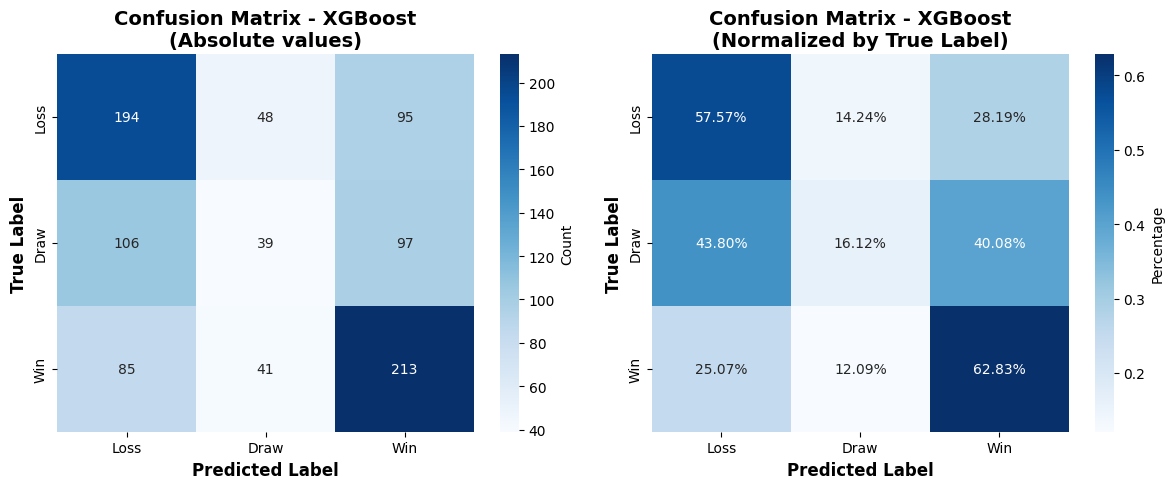

In [91]:
cm=confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
print(f"\nConfusion Matrix")
print(cm)

# Create confusion matrix plot 
fig, axes= plt.subplots(1,2, figsize=(12,5))

# Absolute values
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Loss', 'Draw', 'Win'],
            yticklabels=['Loss', 'Draw', 'Win'],
            cbar_kws={'label' : 'Count'})
axes[0].set_title(f'Confusion Matrix - {best_model_name}\n(Absolute values)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')

# Normalized (Percentages)
cm_normalized=cm.astype('float')/ cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Loss', 'Draw', 'Win'],
            yticklabels=['Loss', 'Draw', 'Win'],
            cbar_kws={'label' : 'Percentage'})
axes[1].set_title(f'Confusion Matrix - {best_model_name}\n(Normalized by True Label)',
                    fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()

# Save confusion matrix plot
cm_path=os.path.join('..','Evaluation', 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Confusion matrix plot saved to {cm_path}")


# Per Class Performance Visualiation

Per class performance plot saved to ..\Evaluation\per_class_performance.png


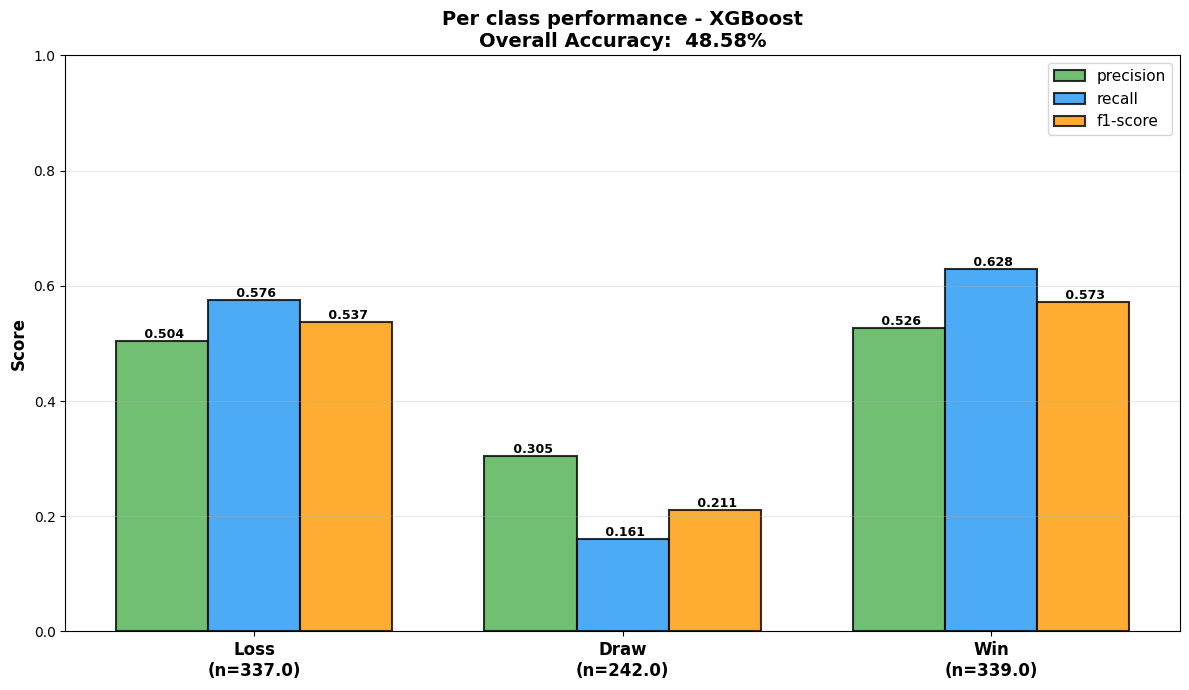

In [92]:
# Per Class Pereformance Visualization
report_dict=classification_report(
    y_test, 
    y_pred, 
    target_names=['Loss', 'Draw', 'Win'],
    output_dict=True
)
classes=['Loss', 'Draw', 'Win']
precision_scores=[report_dict[cls]['precision'] for cls in classes]
recall_scores=[report_dict[cls]['recall'] for cls in classes]
f1_scores=[report_dict[cls]['f1-score'] for cls in classes]
support=[report_dict[cls]['support']for cls in classes]

# Create bar chart
fig, ax=plt.subplots(figsize=(12, 7))
x=np.arange(len(classes))
width=0.25

bars1=ax.bar(x-width, precision_scores, width, label='precision',
             color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2=ax.bar(x, recall_scores, width, label='recall', 
             color='#2196F3', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3=ax.bar(x+width, f1_scores, width, label='f1-score',
             color='#FF9800', alpha=0.8, edgecolor='black', linewidth=1.5)
# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height=bar.get_height()
        ax.text(
            bar.get_x()+bar.get_width()/2., height,
            f'{height: .3f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
# Add support below class names
labels=[f'{cls}\n(n={sup})' for cls, sup in zip(classes, support)]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Per class performance - {best_model_name}\n'
             f'Overall Accuracy: {accuracy: .2%}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save Per Class Performance
per_class__path=os.path.join('..','Evaluation', 'per_class_performance.png')
plt.savefig(per_class__path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Per class performance plot saved to {per_class__path}")

# Feature Importance Visualization


 Top 20 most Important Features:
              Feature  Importance
              is_home    0.074363
        venue_encoded    0.073255
     opponent_encoded    0.043710
           attendance    0.037839
           avg_poss_5    0.037468
       avg_xgoal_diff    0.035523
             points_5    0.033793
         team_encoded    0.033556
           avg_pk_acc    0.033506
        avg_goal_diff    0.033430
               form_5    0.033275
             avg_xg_5    0.033011
opp formation_encoded    0.032759
             avg_sh_5    0.032746
          avg_pkatt_5    0.032745
         avg_shot_acc    0.032523
    formation_encoded    0.032414
           avg_dist_5    0.031982
            avg_xga_5    0.031510
            avg_sot_5    0.031235
Feature importance plot saved to ..\Evaluation\feature_importance.png


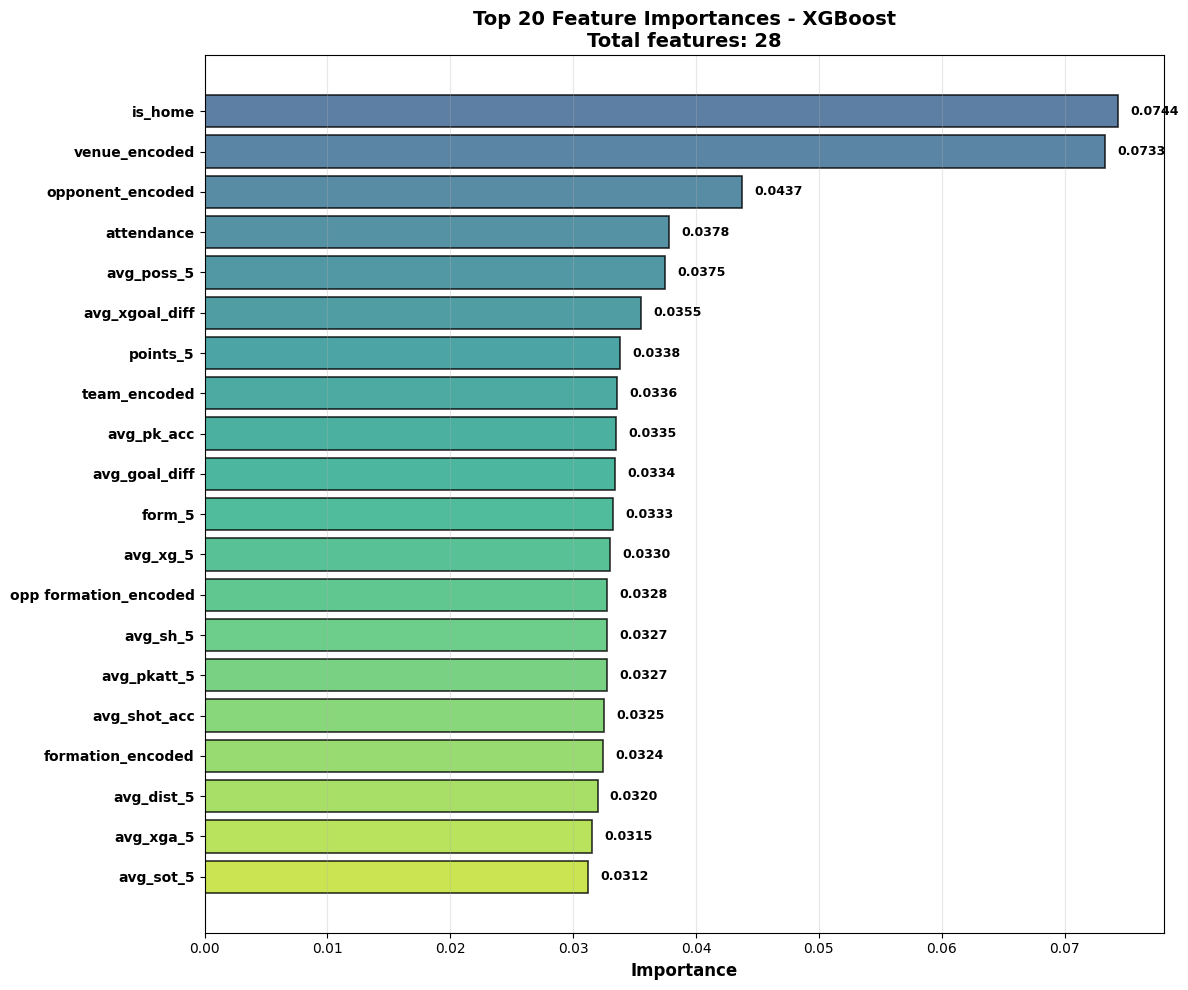

In [93]:
# Feature Importance for tree-based models
if best_model_name in ['Random Forest', 'XGBoost']:
    feature_importances=best_model.feature_importances_
    feat_imp_df=pd.DataFrame({
        'Feature': feature_cols,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)
    print(f"\n Top 20 most Important Features:")
    print(feat_imp_df.head(20).to_string(index=False))

    # Plot Feature Importance
    fig, ax=plt.subplots(figsize=(12,10))
    top_n=20
    top_features=feat_imp_df.head(top_n)
    colors=plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
    bars=ax.barh(range(top_n), top_features['Importance'],
                 color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features['Feature'], fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Feature Importances - {best_model_name}\n'
                 f'Total features: {len(feature_cols)}', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, (idx, row) in enumerate(top_features.iterrows()):
        ax.text(row['Importance'] + 0.001, i, f"{row['Importance']:.4f}",
                va='center', fontsize=9, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    # Save Feature Importance plot
    feat_imp_path=os.path.join('..','Evaluation', 'feature_importance.png')
    feat_imp_csv_path=os.path.join('..','Processed', 'feature_importance.csv')
    top_features.to_csv(feat_imp_csv_path, index=False)
    plt.savefig(feat_imp_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Feature importance plot saved to {feat_imp_path}")

# Feature Importance Intrepretation

In [94]:
# Feature Importane Intrepretation 
top_10=feat_imp_df.head(10)
feature_explanations={
    # Rolling averages
        'avg_gf_5': 'Recent scoring form (goals scored in last 5 matches)',
        'avg_ga_5': 'Recent defensive form (goals conceded in last 5 matches)',
        'avg_goal_diff_5': 'Recent goal difference trend',
        'avg_poss_5': 'Recent possession percentage',
        'avg_xg_5': 'Recent expected goals (quality of chances created)',
        'avg_xga_5': 'Recent expected goals against (quality of chances conceded)',
        'avg_xg_diff_5': 'Recent xG difference (attacking vs defensive quality)',
        'avg_sh_5': 'Recent shooting volume',
        'avg_sot_5': 'Recent shots on target',
        'avg_dist_5': 'Recent average shot distance',
        'avg_shot_accuracy_5': 'Recent shot accuracy (% shots on target)',
        
        # Form indicators
        'form_5': 'Recent form (points in last 5 matches)',
        'points_last_5': 'Points accumulated in last 5 matches',
        
        # Match context
        'is_home': 'Home advantage (1 = home, 0 = away)',
        'attendance': 'Match attendance (crowd support)',
        'venue_encoded': 'Specific stadium/venue',
        'opponent_encoded': 'Quality/identity of opponent',
        'team_encoded': 'Quality/identity of team',
        
        # Tactical
        'formation_encoded': "Team's formation",
        'opp_formation_encoded': "Opponent's formation",
        
        # Temporal
        'year': 'Season year',
        'month': 'Month of season',
        'season': 'Season number',
        'day_of_week_encoded': 'Day of week (weekend vs weekday)'
}
print("Top 10 MOST IMPORTANT FEATURES:\n")
for idx, (_, row) in enumerate(top_10.iterrows(),1):
    feature=row['Feature']
    importance=row['Importance']
    explanation=feature_explanations.get(feature, 'No description available')

    print(f"{idx}. {feature} (Importance: {importance:.4f}) - {explanation}\n")

# Categorize by type
print("\nFeature Categories IN TOP 10:\n")
categories={
    'Recent Form': [],
    'Match context': [],
    'Tactical': [],
    'Temporal': []
}
for _, row in top_10.iterrows():
    feature=row['Feature']
    if 'avg_' in feature or 'form' in feature or 'points' in feature:
        categories['Recent Form'].append(feature)
    elif feature in ['is_home', 'attendance', 'venue_encoded', 'opponent_encoded', 'team_encoded']:
        categories['Match context'].append(feature)
    elif feature in ['formation_encoded', 'opp_formation_encoded']:
        categories['Tactical'].append(feature)
    elif feature in ['year', 'month', 'season', 'day_of_week_encoded']:
        categories['Temporal'].append(feature)
for category, feats in categories.items():
    if feats:
        print(f"{category}: {', '.join(feats)}\n")

print("\nKEY INSIGHTS:\n")

top_1 = top_10.iloc[0]
print(f"1. Most Important Factor: {top_1['Feature']}")
print(f"   {feature_explanations.get(top_1['Feature'], 'N/A')}")
print(f"   This single feature has {top_1['Importance']:.1%} importance!\n")

form_features = [f for f in top_10['Feature'] if 'avg_' in f or 'form' in f]
if form_features:
    print(f"2. Recent Form Dominates: {len(form_features)} of top 10 features are form-based")
    print(f"   The model heavily relies on recent performance trends.\n")

if 'is_home' in top_10['Feature'].values:
    home_rank = list(top_10['Feature']).index('is_home') + 1
    home_imp = top_10[top_10['Feature'] == 'is_home']['Importance'].values[0]
    print(f"3. Home Advantage Matters: Ranked #{home_rank} ({home_imp:.1%})")
    print(f"   Playing at home significantly affects match outcomes.\n")

if 'opponent_encoded' in top_10['Feature'].values:
    opp_rank = list(top_10['Feature']).index('opponent_encoded') + 1
    print(f"4. Opponent Quality: Ranked #{opp_rank}")
    print(f"   Who you play against is more important than tactical details.\n")

# Save insights to file
intrepretation_file=os.path.join('..', 'Evaluation', f'{best_model_name}_feature_interpretation.txt')
with open(intrepretation_file, 'w') as f:
    f.write("Top 10 MOST IMPORTANT FEATURES:\n\n")
    for idx, (_, row) in enumerate(top_10.iterrows(),1):
        feature=row['Feature']
        importance=row['Importance']
        explanation=feature_explanations.get(feature, 'No description available')

        f.write(f"{idx}. {feature} (Importance: {importance:.4f}) - {explanation}\n\n")

    # Categorize by type
    f.write("Feature Categories IN TOP 10:\n\n")
    for category, feats in categories.items():
        if feats:
            f.write(f"{category}: {', '.join(feats)}\n\n")
    f.write("KEY INSIGHTS:\n\n")
    f.write(f"1. Most Important Factor: {top_1['Feature']}\n")
    f.write(f"   {feature_explanations.get(top_1['Feature'], 'N/A')}\n")
    f.write(f"   This single feature has {top_1['Importance']:.1%} importance!\n\n")
    if form_features:
        f.write(f"2. Recent Form Dominates: {len(form_features)} of top 10 features are form-based\n")
        f.write(f"   The model heavily relies on recent performance trends.\n\n")       
    if 'is_home' in top_10['Feature'].values:
        f.write(f"3. Home Advantage Matters: Ranked #{home_rank} ({home_imp:.1%})\n")
        f.write(f"   Playing at home significantly affects match outcomes.\n\n")
    if 'opponent_encoded' in top_10['Feature'].values:
        f.write(f"4. Opponent Quality: Ranked #{opp_rank}\n")
        f.write(f"   Who you play against is more important than tactical details.\n\n")
print(f"Feature interpretation saved to {intrepretation_file}")

Top 10 MOST IMPORTANT FEATURES:

1. is_home (Importance: 0.0744) - Home advantage (1 = home, 0 = away)

2. venue_encoded (Importance: 0.0733) - Specific stadium/venue

3. opponent_encoded (Importance: 0.0437) - Quality/identity of opponent

4. attendance (Importance: 0.0378) - Match attendance (crowd support)

5. avg_poss_5 (Importance: 0.0375) - Recent possession percentage

6. avg_xgoal_diff (Importance: 0.0355) - No description available

7. points_5 (Importance: 0.0338) - No description available

8. team_encoded (Importance: 0.0336) - Quality/identity of team

9. avg_pk_acc (Importance: 0.0335) - No description available

10. avg_goal_diff (Importance: 0.0334) - No description available


Feature Categories IN TOP 10:

Recent Form: avg_poss_5, avg_xgoal_diff, points_5, avg_pk_acc, avg_goal_diff

Match context: is_home, venue_encoded, opponent_encoded, attendance, team_encoded


KEY INSIGHTS:

1. Most Important Factor: is_home
   Home advantage (1 = home, 0 = away)
   This single f

# Model Comparison


 Comparing 3 models

              Model  Accuracy  Precision   Recall  F1 Score (Macro)  F1 Score (Weighted)  Log Loss
            XGBoost  0.485839   0.459517 0.485839          0.440263             0.464296  1.072110
Logistic Regression  0.449891   0.437344 0.449891          0.423060             0.442165  1.046677
      Random Forest  0.466231   0.438810 0.466231          0.422720             0.447602  1.020427


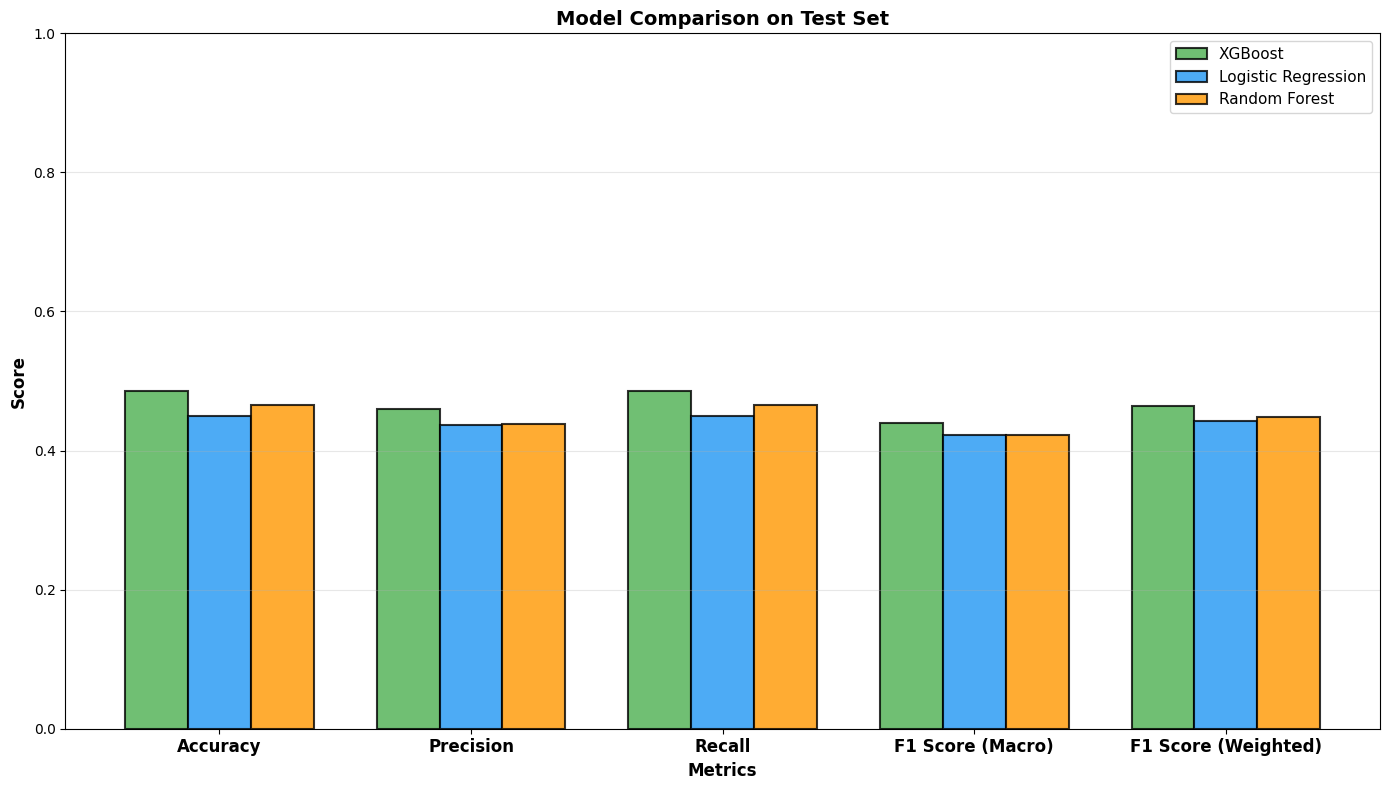

In [95]:
# Model Comparison Summary
if all_models and len(all_models)>1:
    print(f"\n Comparing {len(all_models)} models\n")

    comparison_results=[] 

    for model_name, model in all_models.items():
        # Prepare test data
        if model_name=='Logistic Regression' and scaler:
            X_test_model_comp=scaler.transform(X_test)
        else:
            X_test_model_comp=X_test

        # Handle XGBoost label mapping if needed
        if model_name=='XGBoost':
            y_pred_comp=model.predict(X_test_model_comp)
            y_pred_prob_comp=model.predict_proba(X_test_model_comp)
            y_pred_comp=pd.Series(y_pred_comp).map({0:-1, 1:0, 2:1}).values
            # Map y_test for log_loss calculation
            y_test_mapped=y_test.map({-1:0, 0:1, 1:2})
            ll=log_loss(y_test_mapped, y_pred_prob_comp)
        else:
            y_pred_comp=model.predict(X_test_model_comp)
            y_pred_prob_comp=model.predict_proba(X_test_model_comp)
            ll=log_loss(y_test, y_pred_prob_comp)
        
        # Compute metrics (inside loop, for each model)
        acc=accuracy_score(y_test, y_pred_comp)
        prec=precision_score(y_test, y_pred_comp, average='weighted')
        rec=recall_score(y_test, y_pred_comp, average='weighted')
        f1_mac=f1_score(y_test, y_pred_comp, average='macro')
        f1_wt=f1_score(y_test, y_pred_comp, average='weighted')

        comparison_results.append({
            'Model': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score (Macro)': f1_mac,
            'F1 Score (Weighted)': f1_wt,
            'Log Loss': ll
        })
    
    # After loop - create DataFrame and plot
    comparison_df=pd.DataFrame(comparison_results)
    comparison_df=comparison_df.sort_values('F1 Score (Macro)', ascending=False)
    print(comparison_df.to_string(index=False))

    # Create Comparison Plot
    metrics_to_plot=['Accuracy', 'Precision', 'Recall', 'F1 Score (Macro)', 'F1 Score (Weighted)']
    fig, ax=plt.subplots(figsize=(14,8))
    x=np.arange(len(metrics_to_plot))
    width=0.25
    colors=['#4CAF50', '#2196F3', '#FF9800']
    
    for i, (_, row) in enumerate(comparison_df.iterrows()):
        values=[row[m] for m in metrics_to_plot]
        offset=(i-len(comparison_df)/2)*width + width/2
        ax.bar(x+offset, values, width, label=row['Model'],
               color=colors[i], alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot, fontsize=12, fontweight='bold')
    ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Model Comparison on Test Set', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    # Save Model Comparison Plot
    comp_path=os.path.join('..', 'Evaluation', 'model_comparison.png')
    comp_csv_path=os.path.join('..', 'Processed', 'model_comparison.csv')
    comparison_df.to_csv(comp_csv_path, index=False)
    plt.savefig(comp_path, dpi=300, bbox_inches='tight', facecolor='white')

# Prediction Confidence Analysis


Correct Predictions: 446 (48.58%)
Average confidence (correct) : 0.6252
Median confidence (correct): 0.6058

Incorrect Predictions: 472 (51.42%)
Average confidence (incorrect): 0.5602
Median confidence (incorrect): 0.5340
Prediction confidence plot saved to ..\Evaluation\prediction_confidence.png


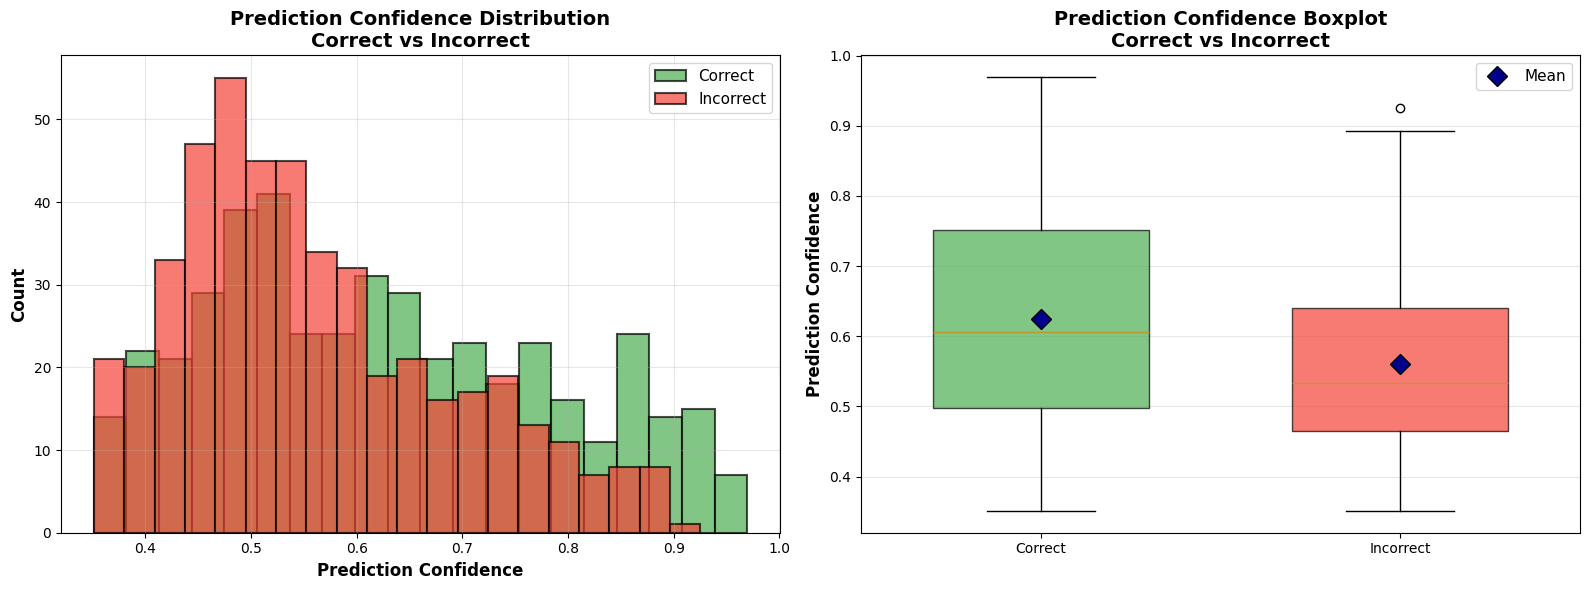

In [96]:
# Get Max probability for each prediction
max_probs=y_pred_prob.max(axis=1)

# Analyze confidence by correctness
correct_mask=(y_pred==y_test.values)
correct_probs=max_probs[correct_mask]
incorrect_probs=max_probs[~correct_mask]

print(f"\nCorrect Predictions: {correct_mask.sum()} ({correct_mask.sum()/len(y_test)*100:.2f}%)")
print(f"Average confidence (correct) : {correct_probs.mean():.4f}")
print(f"Median confidence (correct): {np.median(correct_probs):.4f}")

print(f"\nIncorrect Predictions: {(~correct_mask).sum()} ({(~correct_mask).sum()/len(y_test)*100:.2f}%)")
print(f"Average confidence (incorrect): {incorrect_probs.mean():.4f}")
print(f"Median confidence (incorrect): {np.median(incorrect_probs):.4f}")

# Plot confidence distributions
fig, axes=plt.subplots(1, 2, figsize=(16,6))

# Histogram
axes[0].hist(correct_probs, bins=20, alpha=0.7, label='Correct', color='#4CAF50', 
             edgecolor='black', linewidth=1.5)
axes[0].hist(incorrect_probs, bins=20, alpha=0.7, label='Incorrect', color='#F44336',
             edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Prediction Confidence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Prediction Confidence Distribution\nCorrect vs Incorrect', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Boxplot
box_data=[correct_probs, incorrect_probs]
bp=axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel('Prediction Confidence', fontsize=12, fontweight='bold')
axes[1].set_title('Prediction Confidence Boxplot\nCorrect vs Incorrect', fontsize=14, fontweight='bold')
axes[1].grid(axis='y',alpha=0.3)

for i, data in enumerate(box_data,1):
    axes[1].plot(i, data.mean(), 'D', markersize=10, color='darkblue', markeredgecolor='black',
                 linewidth=1.5, label='Mean' if i==1 else '')
axes[1].legend(fontsize=11)
plt.tight_layout()
cf_path=os.path.join('..', 'Evaluation', 'prediction_confidence.png')
plt.savefig(cf_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Prediction confidence plot saved to {cf_path}")